# 06 — Classifier Comparison & ITR Sweep

**Owner:** Ishanvir & Yuki

**Reference:** Wolpaw, J. R., et al. (1998). *EEG-based communication: improved accuracy by response verification.* IEEE Trans. Rehabil. Eng. 6(3):326–333. (ITR formula)

**This notebook is a pedagogical wrapper** around `scripts/compare_classifiers.py`. It imports the script's per-classifier evaluation helpers, runs them at 3.0 s window with H=2, assembles the headline comparison table, renders the headline figure inline, and sweeps ITR across windows.


| Classifier | Accuracy | ITR (bpm) |
|---|---|---|
| CCA-8ch | 0.838 | 22.0 |
| CCA-top4-nested | 0.850 | 23.0 |
| FBCCA | 0.950 | 32.7 |
| TRCA | 0.312 | 0.3 |
| CH11 | 0.872 on fired (49% coverage) | n/a |


In [ ]:
import os, sys
from pathlib import Path
_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / 'data' / 'raw').exists()), None)
if _root and Path.cwd() != _root:
    os.chdir(_root)
ROOT = Path.cwd()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

# Make scripts/ importable for the per-classifier helpers
sys.path.insert(0, str(ROOT / 'scripts'))

from ssvep.io import load_all
from ssvep.evaluation import itr
from compare_classifiers import (
    eval_cca_8ch, eval_cca_top4_nested, eval_fbcca, eval_trca, eval_ch11,
    within_subject_lobo_cv, eval_cca_top4_within_subject, WITHIN_SUBJECT_FOLDS,
)
from ssvep.classifiers import CCAClassifier, FBCCAClassifier, TRCAClassifier


## 1. Run all classifiers (cross-subject 4-block LOBO, 3 s, H=2)

These are the same eval helpers `scripts/compare_classifiers.py` calls. The script writes to `results/tables/comparison_3s.csv`; this notebook computes them inline.


In [ ]:
d = load_all(window_s=3.0)
X, y, blocks = d['X'], d['y'], d['blocks']
fs, sf, ch_names = d['fs'], d['stim_freqs'], d['ch_names']
n_harmonics = 2

print('Running CCA-8ch ...')
res_cca   = eval_cca_8ch(X, y, blocks, sf, fs, n_harmonics)
print('Running CCA-top4-nested ...')
res_top4  = eval_cca_top4_nested(X, y, blocks, sf, fs, n_harmonics, ch_names)
print('Running FBCCA ...')
res_fbcca = eval_fbcca(X, y, blocks, sf, fs, n_harmonics)
print('Running TRCA ...')
res_trca  = eval_trca(X, y, blocks, sf, fs)
print('Running CH11 ...')
res_ch11  = eval_ch11(d)
print('done.')


Running CCA-8ch ...


Running CCA-top4-nested ...


Running FBCCA ...


Running TRCA ...


Running CH11 ...
done.


## 2. Headline comparison table

Should match `results/tables/comparison_3s.csv` row-for-row.


In [ ]:
rows = []
for name, res in [('CCA-8ch', res_cca), ('CCA-top4-nested', res_top4),
                  ('FBCCA', res_fbcca), ('TRCA', res_trca)]:
    rows.append({
        'classifier': name,
        'accuracy': round(res['mean'], 3),
        'std': round(res['std'], 3),
        'itr_bpm': round(itr(res['mean'], n_classes=4, window_s=3.0), 1),
        'notes': ' | '.join(f'b{b}={v:.2f}' for b, v in res['per_block'].items()),
    })
rows.append({
    'classifier': 'CH11',
    'accuracy': round(res_ch11['mean'], 3),
    'std': 'n/a',
    'itr_bpm': 'n/a',
    'notes': f"fired {res_ch11['n_fired']}/{res_ch11['n_total']} trials "
             f"({res_ch11['coverage']:.0%} coverage); acc_all={res_ch11['acc_all']:.3f}",
})
df = pd.DataFrame(rows)
df


,classifier,accuracy,std,itr_bpm,notes
0,CCA-8ch,0.838,0.163,22.0,b0=1.00 | b1=1.00 | b2=0.70 | b3=0.65
1,CCA-top4-nested,0.850,0.15,23.0,b0=1.00 | b1=1.00 | b2=0.70 | b3=0.70
2,FBCCA,0.950,0.061,32.7,b0=1.00 | b1=1.00 | b2=0.85 | b3=0.95
3,TRCA,0.312,0.041,0.3,b0=0.25 | b1=0.30 | b2=0.35 | b3=0.35
4,CH11,0.872,n/a,n/a,fired 39/80 trials (49% coverage); acc_all=0.425


## 3. Headline figure

Generated by `scripts/compare_classifiers.py --window 3.0 --harmonics 2` (cross-subject default). Embedded here from the canonical artifact.


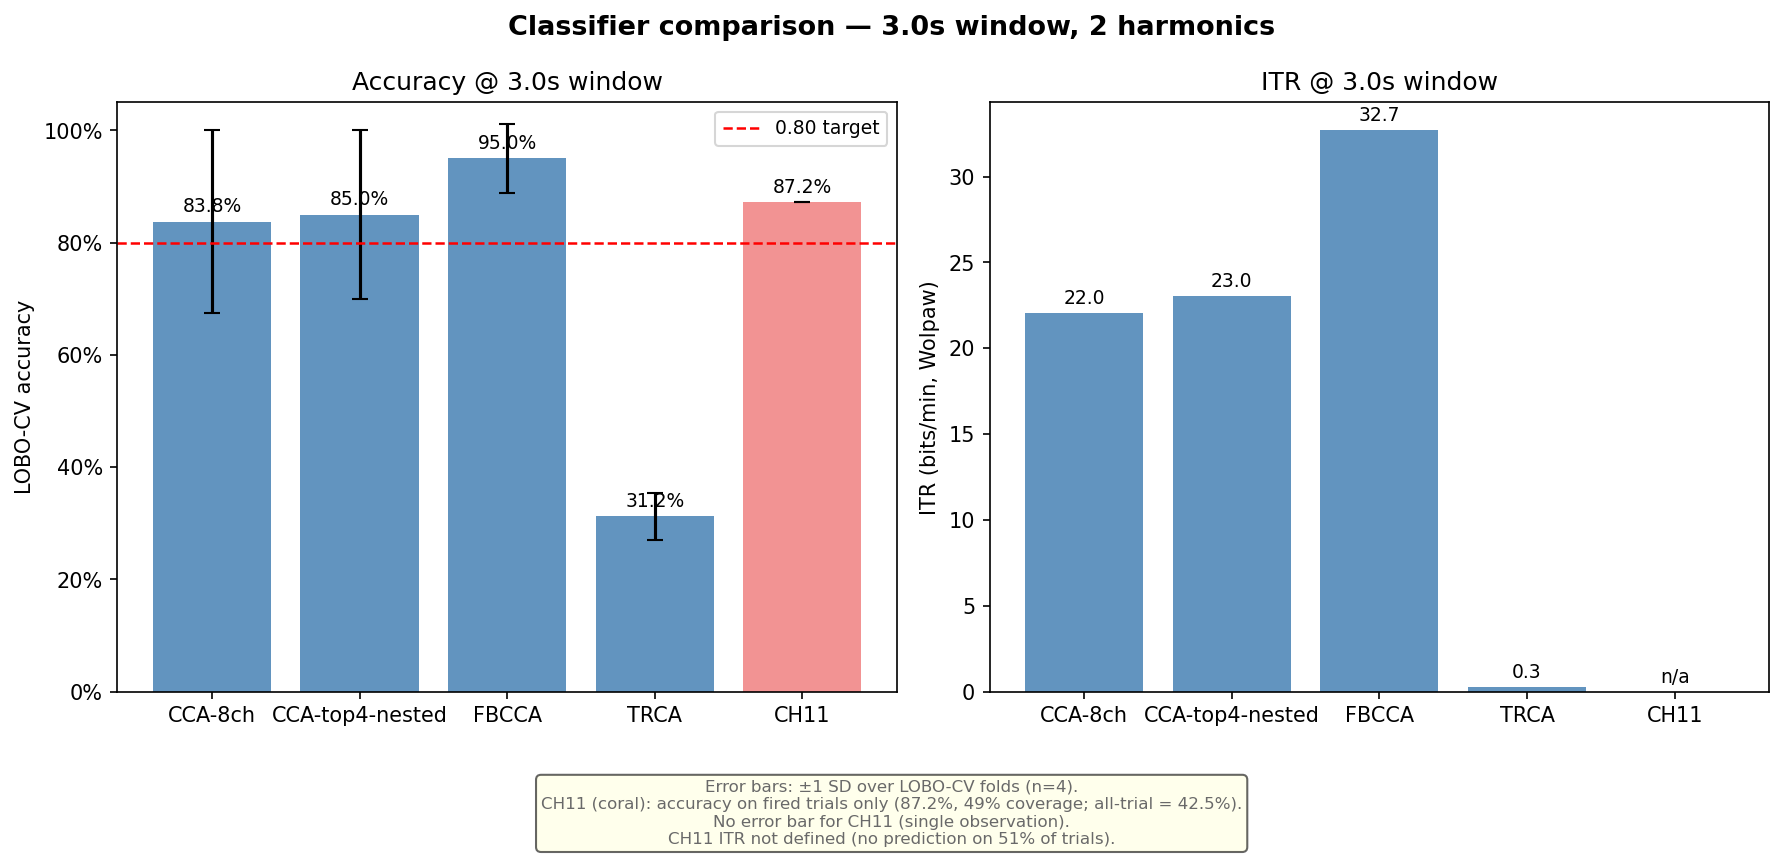

In [ ]:
Image(filename=str(ROOT / 'results' / 'figures' / 'comparison.png'))


## 4. ITR sweep across windows

Per-classifier accuracy + Wolpaw ITR at 1, 2, 3, 5 s windows. **Anchor (peak ITR):** FBCCA @ 1 s = 57.7 bpm, matching `comparison_1s.csv` (also `comparison_within_subject_1s.csv`, since CCA/FBCCA are protocol-invariant).


In [ ]:
sweep_rows = []
for win in [1.0, 2.0, 3.0, 5.0]:
    ds = load_all(window_s=win)
    for clf_name, fn in [
        ('CCA-8ch', lambda ds=ds: eval_cca_8ch(ds['X'], ds['y'], ds['blocks'], ds['stim_freqs'], ds['fs'], 2)),
        ('FBCCA',   lambda ds=ds: eval_fbcca(ds['X'], ds['y'], ds['blocks'], ds['stim_freqs'], ds['fs'], 2)),
        ('TRCA',    lambda ds=ds: eval_trca(ds['X'], ds['y'], ds['blocks'], ds['stim_freqs'], ds['fs'])),
    ]:
        r = fn()
        sweep_rows.append({
            'window_s': win, 'classifier': clf_name,
            'accuracy': round(r['mean'], 3),
            'itr_bpm': round(itr(r['mean'], 4, win), 1),
        })
sweep_df = pd.DataFrame(sweep_rows).pivot(index='window_s', columns='classifier', values=['accuracy', 'itr_bpm'])
sweep_df


accuracy               itr_bpm           
classifier  CCA-8ch  FBCCA   TRCA CCA-8ch FBCCA TRCA
window_s                                            
1.0           0.700  0.800  0.312    38.6  57.7  0.9
2.0           0.775  0.938  0.375    26.2  46.9  1.6
3.0           0.838  0.950  0.312    22.0  32.7  0.3
5.0           0.850  0.975  0.362    13.8  21.5  0.5

## 5. Per-subject decomposition (within-subject LOBO, 3 s)

`compare_classifiers.py --protocol within_subject` runs each classifier under the Nakanishi 2018 protocol and the script prints per-subject means. Reproducing the same breakdown here.


In [ ]:
# Within-subject LOBO at 3 s, H=2
fold_pairs = WITHIN_SUBJECT_FOLDS    # [(0,1),(1,0),(2,3),(3,2)] — subj 1 first, subj 2 last

cca_factory   = lambda: CCAClassifier(stim_freqs=sf, fs=fs, n_harmonics=n_harmonics)
fbcca_factory = lambda: FBCCAClassifier(stim_freqs=sf, fs=fs, num_harmonics=n_harmonics)
trca_factory  = lambda: TRCAClassifier(stim_freqs=sf, fs=fs, ensemble=True)

results_w = {
    'CCA-8ch':  within_subject_lobo_cv(X, y, blocks, cca_factory),
    'CCA-top4': eval_cca_top4_within_subject(X, y, blocks, sf, fs, n_harmonics),
    'FBCCA':    within_subject_lobo_cv(X, y, blocks, fbcca_factory),
    'TRCA':     within_subject_lobo_cv(X, y, blocks, trca_factory),
}

per_subj_rows = []
for name, r in results_w.items():
    accs_in_fold_order = list(r['per_block'].values())
    s1 = float(np.mean(accs_in_fold_order[:2]))
    s2 = float(np.mean(accs_in_fold_order[2:]))
    per_subj_rows.append({
        'classifier': name, 'mean': round(r['mean'], 3),
        'subj 1': round(s1, 3), 'subj 2': round(s2, 3),
    })
pd.DataFrame(per_subj_rows)


,classifier,mean,subj 1,subj 2
0,CCA-8ch,0.837,1.000,0.675
1,CCA-top4,0.850,1.000,0.700
2,FBCCA,0.950,1.000,0.900
3,TRCA,0.475,0.675,0.275


## 6. Takeaway

**Algorithmic priors > learned filters when training data is scarce.** With 5 trials per class (the regime of within-subject LOBO on this dataset), the priors baked into CCA's reference structure (canonical sin/cos at the candidate frequencies) and FBCCA's filter-bank weighting (sub-band weights matched to SSVEP harmonic structure) outperform TRCA's data-driven spatial-filter learning. The reason is straightforward: at 5 trials per class, the eigenvalue solver's S/Q matrices don't have enough pairwise scatter information to identify a stable maximum-reproducibility direction. CCA needs no training; FBCCA needs no training; TRCA needs more than this dataset provides.

**FBCCA's 100% trial coverage matters as much as its accuracy.** CH11 (g.tec's live LDA) hits 87.2% on the trials where it actually fires, but it only fires on 49% of trials. The practical all-trial accuracy collapses to 42.5%. FBCCA fires on 100% of trials at 95.0% accuracy. For a real-world speller where every trial must produce a decision, the 95.0% × 100% headline number is the one that matters.

**Where to next:** notebook 08 (Yuki's per-subject channel selection) shows that fewer carefully chosen channels can match or beat the full 8-channel montage, especially on subject 2. The full provenance audit verifying every number in this notebook is in `results/audit_report.md`.
